In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windfield import WindField
from tracer import solver, initial_velocity, fetch_wind_data

### Reading data

In [31]:
# Data from tour averages for the men's (PGA) and women's (LPGA) golf turnaments
# from https://www.trackman.com/blog/golf/introducing-updated-tour-averages

pga_data = [
    ["Driver", 115, -0.9, 171, 1.49, 10.4, 2545, 32, 39, 258],
    ["3-wood", 110, -2.3, 162, 1.47, 9.3, 3663, 29, 44, 228],
    ["5-wood", 106, -2.5, 156, 1.47, 9.7, 4322, 30, 48, 216],
    ["Hybrid", 102, -2.4, 149, 1.47, 10.2, 4587, 28, 49, 211],
    ["3 Iron", 100, -2.5, 145, 1.46, 10.3, 4404, 27, 48, 199],
    ["4 Iron", 98, -2.9, 140, 1.44, 10.8, 4782, 28, 49, 192],
    ["5 Iron", 96, -3.4, 135, 1.41, 11.9, 5280, 30, 50, 182],
    ["6 Iron", 94, -3.7, 130, 1.39, 14.0, 6204, 29, 50, 172],
    ["7 Iron", 92, -3.9, 123, 1.34, 16.1, 7124, 31, 51, 161],
    ["8 Iron", 89, -4.2, 118, 1.33, 17.8, 8078, 30, 51, 150],
    ["9 Iron", 87, -4.3, 112, 1.29, 20.0, 8793, 29, 52, 139],
    ["PW", 84, -4.7, 104, 1.24, 23.7, 9316, 29, 52, 130],
]

lpga_data = [
    ["Driver", 96, 2.8, 143, 1.49, 12.6, 2506, 24, 36, 204],
    ["3-wood", 92, -0.8, 135, 1.47, 11.6, 2595, 23, 38, 183],
    ["5-wood", 90, -1.6, 130, 1.46, 12.3, 4320, 23, 43, 173],
    ["Hybrid", 87, -1.9, 125, 1.44, 13.9, 4504, 23, 45, 163],
    ["4 Iron", 82, -1.7, 118, 1.43, 13.9, 4608, 23, 43, 160],
    ["5 Iron", 81, -2.0, 114, 1.42, 14.6, 4966, 23, 45, 152],
    ["6 Iron", 80, -2.3, 111, 1.41, 16.7, 5904, 23, 46, 142],
    ["7 Iron", 78, -2.5, 106, 1.38, 18.5, 6630, 24, 47, 131],
    ["8 Iron", 76, -2.8, 102, 1.36, 20.8, 7413, 25, 47, 122],
    ["9 Iron", 74, -3.2, 95, 1.30, 23.5, 7605, 25, 48, 112],
    ["PW", 72, -3.2, 88, 1.25, 25.2, 8465, 25, 48, 101],
]

columns = [
    "Club",
    "Club Speed (mph)",
    "Attack Angle (deg)",
    "Ball Speed (mph)",
    "Smash Factor",
    "Launch Angle (deg)",
    "Spin Rate (rpm)",
    "Max Height (m)",
    "Land Angle (deg)",
    "Carry (m)"
]

df_pga = pd.DataFrame(pga_data, columns=columns)
df_lpga = pd.DataFrame(lpga_data, columns=columns)


# convert from mph to m/s
df_pga['Ball Speed (mph)'] = df_pga['Ball Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_pga['Club Speed (mph)'] = df_pga['Club Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

df_lpga['Ball Speed (mph)'] = df_lpga['Ball Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_lpga['Club Speed (mph)'] = df_lpga['Club Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

display(df_pga)
display(df_lpga)

,Club,Club Speed (m/s),Attack Angle (deg),Ball Speed (m/s),Smash Factor,Launch Angle (deg),Spin Rate (rpm),Max Height (m),Land Angle (deg),Carry (m)
0,Driver,51.40960,-0.9,76.44384,1.49,10.4,2545,32,39,258
1,3-wood,49.17440,-2.3,72.42048,1.47,9.3,3663,29,44,228
2,5-wood,47.38624,-2.5,69.73824,1.47,9.7,4322,30,48,216
3,Hybrid,45.59808,-2.4,66.60896,1.47,10.2,4587,28,49,211
4,3 Iron,44.70400,-2.5,64.82080,1.46,10.3,4404,27,48,199
5,4 Iron,43.80992,-2.9,62.58560,1.44,10.8,4782,28,49,192
6,5 Iron,42.91584,-3.4,60.35040,1.41,11.9,5280,30,50,182
7,6 Iron,42.02176,-3.7,58.11520,1.39,14.0,6204,29,50,172
8,7 Iron,41.12768,-3.9,54.98592,1.34,16.1,7124,31,51,161
9,8 Iron,39.78656,-4.2,52.75072,1.33,17.8,8078,30,51,150


,Club,Club Speed (m/s),Attack Angle (deg),Ball Speed (m/s),Smash Factor,Launch Angle (deg),Spin Rate (rpm),Max Height (m),Land Angle (deg),Carry (m)
0,Driver,42.91584,2.8,63.92672,1.49,12.6,2506,24,36,204
1,3-wood,41.12768,-0.8,60.35040,1.47,11.6,2595,23,38,183
2,5-wood,40.23360,-1.6,58.11520,1.46,12.3,4320,23,43,173
3,Hybrid,38.89248,-1.9,55.88000,1.44,13.9,4504,23,45,163
4,4 Iron,36.65728,-1.7,52.75072,1.43,13.9,4608,23,43,160
5,5 Iron,36.21024,-2.0,50.96256,1.42,14.6,4966,23,45,152
6,6 Iron,35.76320,-2.3,49.62144,1.41,16.7,5904,23,46,142
7,7 Iron,34.86912,-2.5,47.38624,1.38,18.5,6630,24,47,131
8,8 Iron,33.97504,-2.8,45.59808,1.36,20.8,7413,25,47,122
9,9 Iron,33.08096,-3.2,42.46880,1.30,23.5,7605,25,48,112


## Error calculations

In [32]:
P0 = [0,0,0]
wind = WindField(nx=300, ny=500, nz=100, direction=0, profile='log', z0=0.01)

In [33]:
carry_pga = []
maxheight_pga = []

for i in range(len(df_pga)):
    V0 = initial_velocity(speed=df_pga['Ball Speed (m/s)'][i], angle=df_pga['Launch Angle (deg)'][i])
    W0 = np.array([0, -df_pga['Spin Rate (rpm)'][i], 0])
    t, p, v, w = solver(P0, V0, W0, wind, dt=0.01)
    
    carry = (p[-1][0]- p[0][0])
    max_height = max(p[:,2])

    carry_pga.append(carry)
    maxheight_pga.append(max_height)

print(carry_pga)
print(maxheight_pga)

[np.float64(240.81259926842162), np.float64(226.18744545901708), np.float64(218.98984533249669), np.float64(206.34301977742393), np.float64(195.94400312342518), np.float64(187.99394387236532), np.float64(181.789856074382), np.float64(177.34788720202383), np.float64(164.95831897600627), np.float64(154.5758655591306), np.float64(141.39682527334503), np.float64(124.54466768105492)]
[np.float64(22.767102602638527), np.float64(20.16255856798441), np.float64(20.529892073341728), np.float64(19.46081779004239), np.float64(17.704625886987092), np.float64(17.519154232706658), np.float64(18.434025483077345), np.float64(21.409036410306584), np.float64(22.71693857445685), np.float64(23.816934710014117), np.float64(24.181198945615932), np.float64(24.509784634449254)]


In [34]:
carry_lpga = []
maxheight_lpga = []

for i in range(len(df_lpga)):
    V0 = initial_velocity(speed=df_lpga['Ball Speed (m/s)'][i], angle=df_lpga['Launch Angle (deg)'][i])
    W0 = np.array([0, -df_lpga['Spin Rate (rpm)'][i], 0])
    t, p, v, w = solver(P0, V0, W0, wind, dt=0.01)
    
    carry = (p[-1][0]- p[0][0])
    max_height = max(p[:,2])

    carry_lpga.append(carry)
    maxheight_lpga.append(max_height)

print(carry_lpga)
print(maxheight_lpga)


[np.float64(186.37194256848377), np.float64(164.0490716143831), np.float64(166.31323235552193), np.float64(160.07864318705592), np.float64(144.35099413071873), np.float64(138.48401036928794), np.float64(138.71665698455314), np.float64(131.4997138860988), np.float64(125.21278825173958), np.float64(112.86939590040805), np.float64(98.56532354249488)]
[np.float64(17.3885788941332), np.float64(13.353443118370505), np.float64(15.543559121897829), np.float64(16.461721243504602), np.float64(14.152095934753113), np.float64(14.139886364075247), np.float64(16.771427311575707), np.float64(17.664292502392666), np.float64(19.231538793633263), np.float64(19.01773513216447), np.float64(17.79692960987238)]


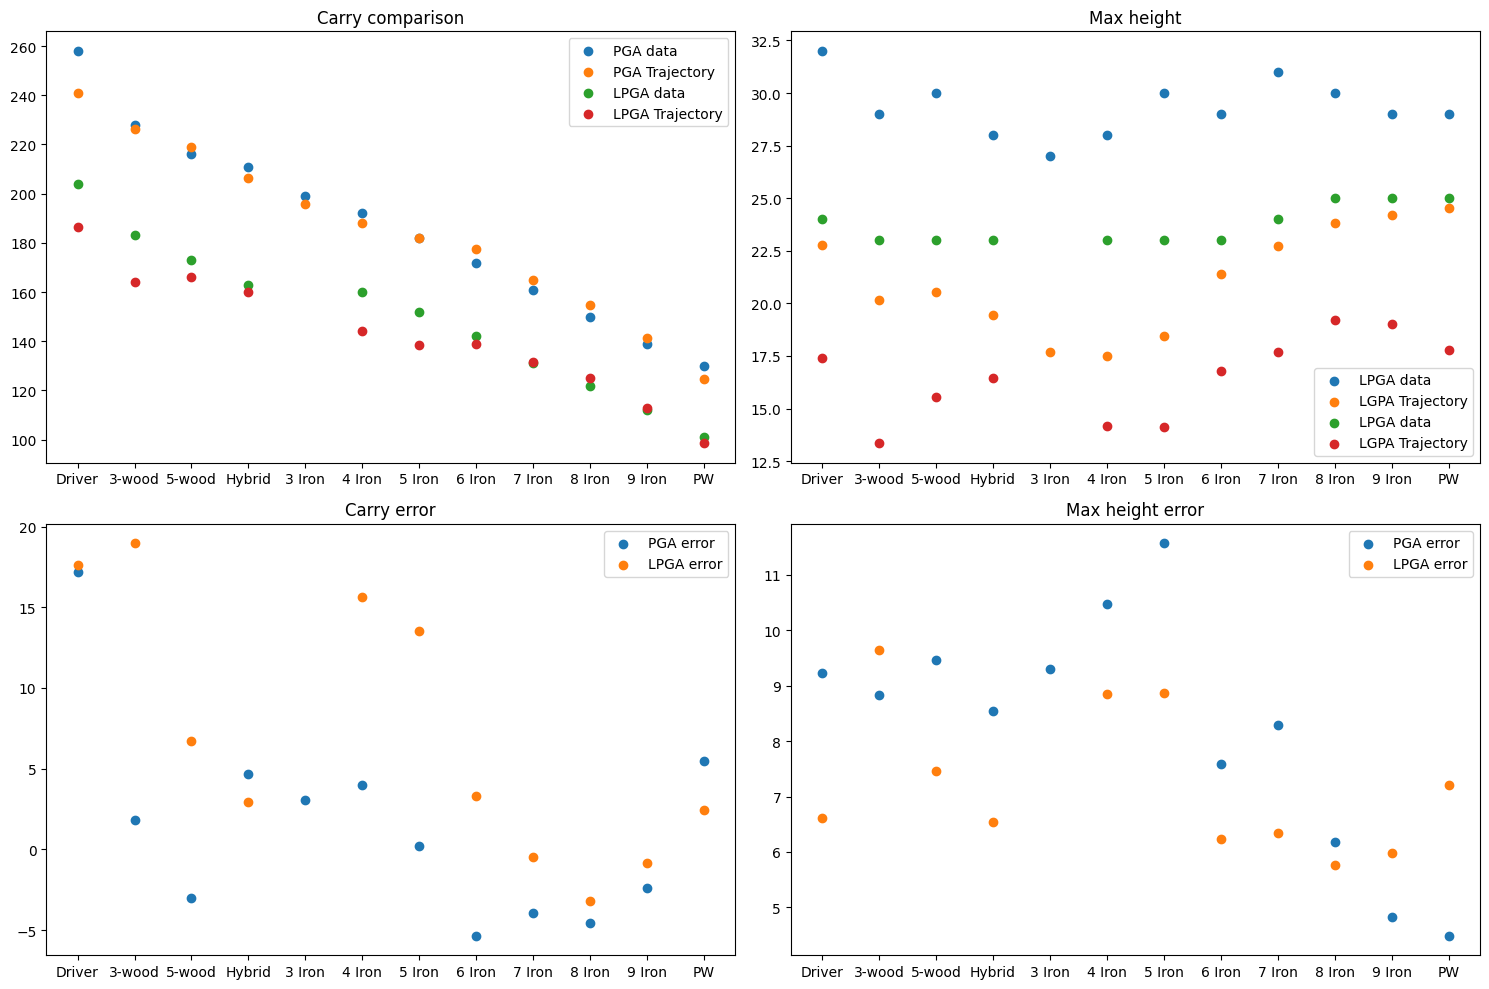

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-left
axes[0, 0].scatter(df_pga['Club'], df_pga['Carry (m)'],label='PGA data')
axes[0, 0].scatter(df_pga['Club'], carry_pga, label='PGA Trajectory')
axes[0, 0].scatter(df_lpga['Club'], df_lpga['Carry (m)'],label='LPGA data')
axes[0, 0].scatter(df_lpga['Club'], carry_lpga, label='LPGA Trajectory')
axes[0, 0].set_title("Carry comparison")
axes[0, 0].legend()

# Top-right
axes[0, 1].scatter(df_pga['Club'], df_pga['Max Height (m)'],label='LPGA data')
axes[0, 1].scatter(df_pga['Club'], maxheight_pga, label='LGPA Trajectory')
axes[0, 1].scatter(df_lpga['Club'], df_lpga['Max Height (m)'],label='LPGA data')
axes[0, 1].scatter(df_lpga['Club'], maxheight_lpga, label='LGPA Trajectory')
axes[0, 1].set_title("Max height")
axes[0, 1].legend()

def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

# Bottom-left
axes[1, 0].scatter(df_pga['Club'], df_pga['Carry (m)'] - carry_pga, label='PGA error')
axes[1, 0].scatter(df_lpga['Club'], df_lpga['Carry (m)'] - carry_lpga, label='LPGA error')
axes[1, 0].set_title("Carry error")
axes[1, 0].legend()

# Bottom-right
axes[1, 1].scatter(df_pga['Club'], df_pga['Max Height (m)'] - maxheight_pga, label='PGA error')
axes[1, 1].scatter(df_lpga['Club'], df_lpga['Max Height (m)'] - maxheight_lpga, label='LPGA error')
axes[1, 1].set_title("Max height error")
axes[1, 1].legend()

plt.tight_layout()
plt.show()